In [3]:
import astropy.io.fits as fits
import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import aplpy
import glob
import os
import pandas as pd

from create_figs import create_m8_map

import warnings
warnings.filterwarnings("ignore")

This notebook creates figures with the outflow and separation vectors plotted and creates a histogram of the angles.

In [4]:
def angle_between_vectors(v1, v2):
    """Calculate the angle (in degrees) between two vectors."""
    dot_product = np.dot(v1, v2)  # Compute dot product
    norm_v1 = np.linalg.norm(v1)  # Compute magnitude of v1
    norm_v2 = np.linalg.norm(v2)  # Compute magnitude of v2
    
    # Compute angle in radians and then convert to degrees
    angle_rad = np.arccos(dot_product / (norm_v1 * norm_v2))
    angle_deg = np.degrees(angle_rad)
    
    return angle_deg

In [ ]:
source_info = pd.read_csv("../data/source_info.csv")

In [6]:
measured_outflows = [
    "HH270VLA1",
    "HOPS-12",
    "HOPS-32",
    "HOPS-84",
    "HOPS-168",
    "HOPS-281",
    "HOPS-312",
    "HOPS-364",
    "HOPS-395",
    "HOPS-400",
    "HOPS-290",
    "HOPS-92",
    "HOPS-182",
    "HOPS-288",
    "HOPS-323",
    "HOPS-203",
]
angles = [
    50.0425,
    157.1225,
    159.045,
    82.815,
    159.35,
    26.02,
    216.3725,
    276.3025,
    174.1675,
    266.645,
    293.5175,
    76.03,
    234.6425,
    55.9875,
    303.09,
    143.81,
]

In [7]:
df = pd.DataFrame(list(zip(measured_outflows, angles)), columns=["Main", "Angle"])
df2 = source_info[source_info["Main"].isin(measured_outflows)]
sources = pd.merge(df2, df, how='outer', left_on="Main", right_on="Main").set_index("Main")
exclusions = ["HOPS-12-A", "HOPS-92-B", "HOPS-182-C", "HOPS-288-B", "HOPS-203-C"]
sources = sources[~sources['Source'].isin(exclusions)]
overwrite = False

INFO: Auto-setting vmin to -5.459e-04 [aplpy.core]
INFO: Auto-setting vmax to  6.960e-02 [aplpy.core]
INFO: Auto-setting vmin to  5.362e-03 [aplpy.core]
INFO: Auto-setting vmax to  6.678e-02 [aplpy.core]


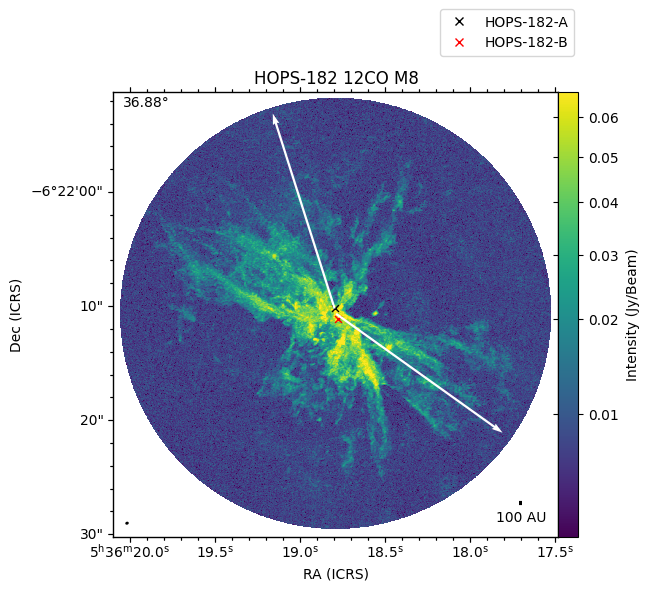

INFO: Auto-setting vmin to -1.191e-03 [aplpy.core]
INFO: Auto-setting vmax to  6.658e-02 [aplpy.core]
INFO: Auto-setting vmin to  4.415e-03 [aplpy.core]
INFO: Auto-setting vmax to  5.367e-02 [aplpy.core]


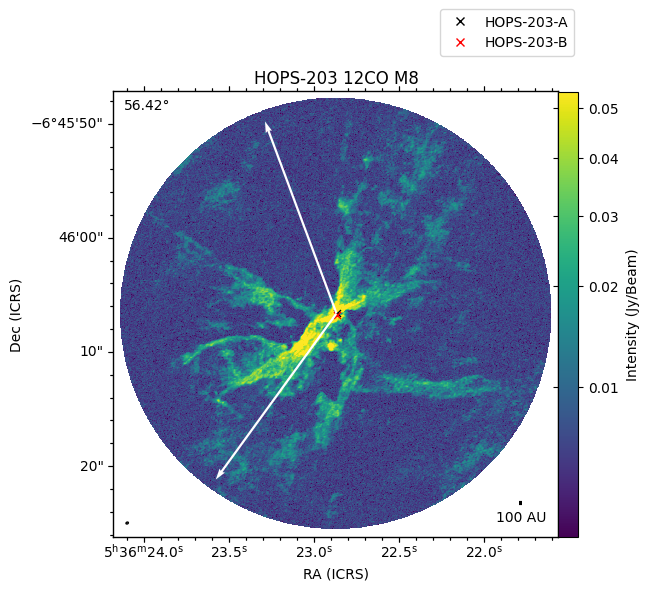

INFO: Auto-setting vmin to -1.172e-03 [aplpy.core]
INFO: Auto-setting vmax to  6.617e-02 [aplpy.core]
INFO: Auto-setting vmin to  4.429e-03 [aplpy.core]
INFO: Auto-setting vmax to  6.786e-02 [aplpy.core]


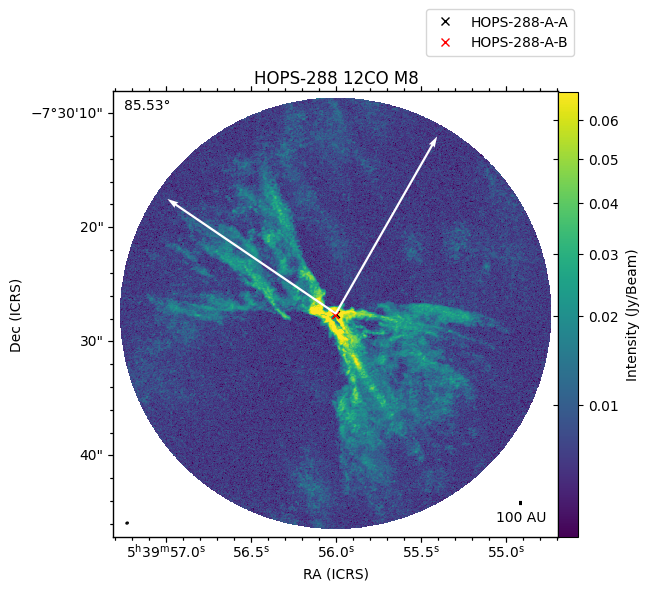

INFO: Auto-setting vmin to  1.163e-04 [aplpy.core]
INFO: Auto-setting vmax to  5.177e-02 [aplpy.core]
INFO: Auto-setting vmin to  4.306e-03 [aplpy.core]
INFO: Auto-setting vmax to  4.735e-02 [aplpy.core]


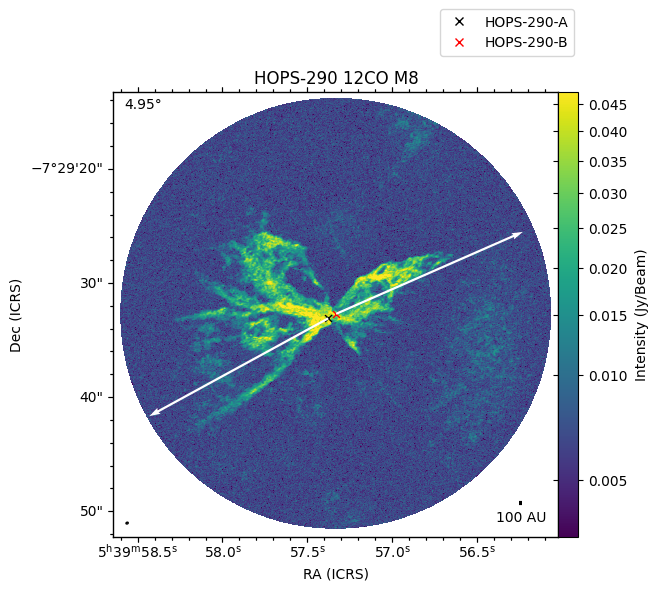

INFO: Auto-setting vmin to -6.331e-03 [aplpy.core]
INFO: Auto-setting vmax to  1.092e-01 [aplpy.core]
INFO: Auto-setting vmin to  3.202e-03 [aplpy.core]
INFO: Auto-setting vmax to  9.040e-02 [aplpy.core]


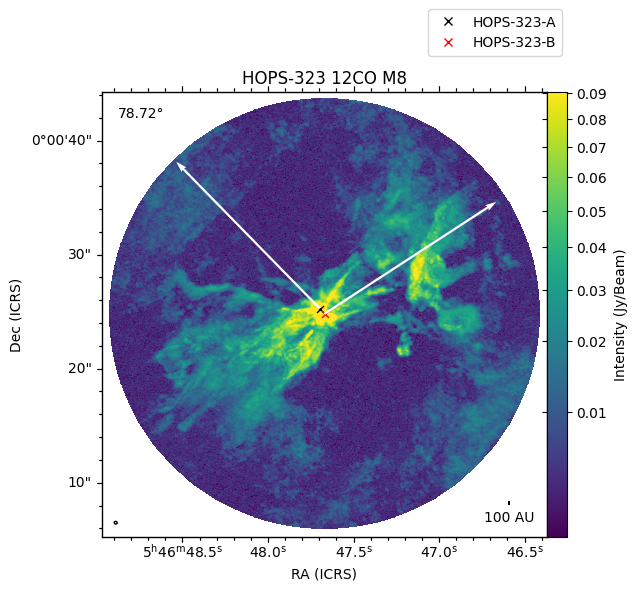

INFO: Auto-setting vmin to -1.504e-03 [aplpy.core]
INFO: Auto-setting vmax to  7.126e-02 [aplpy.core]
INFO: Auto-setting vmin to  4.465e-03 [aplpy.core]
INFO: Auto-setting vmax to  6.441e-02 [aplpy.core]


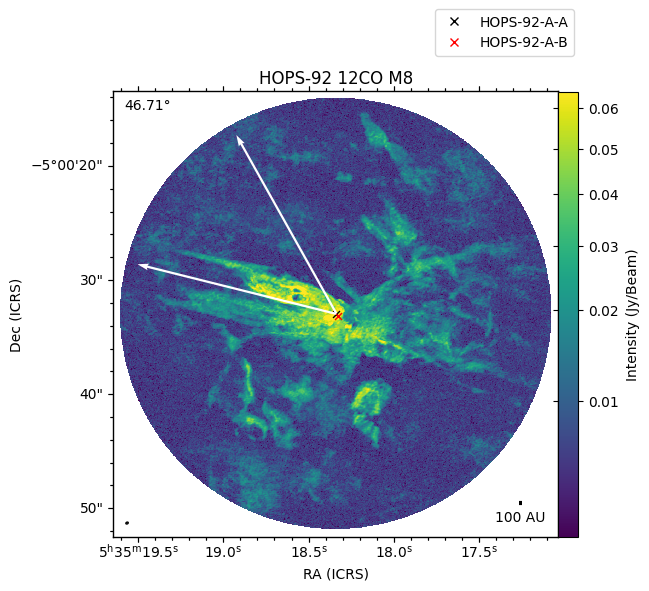

In [ ]:
# This loops through each source field with an angle measurement and creates
# a figure with the separation vector an outflow vector overlayed
smallest_angles = []
for target_name, group in sources.groupby("Main"):


    # verify output path exists and
    # skip already existing files if you don't want to overwrite them
    output_path = f"../results/outflow_alignment/{target_name}_outflow.png"
    if (os.path.exists(output_path)) and (not overwrite):
        continue

    # open image
    hdulist = fits.open(f"/Volumes/Alpha/Research/data/{target_name.casefold()}/{target_name.casefold()}__s15__12co.fits")
    hdu = hdulist[0]

    # extract center coords
    center_ra = hdu.header['OBSRA']
    center_dec = hdu.header['OBSDEC']

    # set center and size of cutout
    center = SkyCoord(center_ra, center_dec, unit=u.degree)
    size = np.array([39, 39]) * u.arcsecond

    fig = create_m8_map(hdu, center, size, distance=group.iloc[0]['Dis'])
    fig.set_title(f"{target_name} 12CO M8")
    fig.show_colorscale(cmap='viridis', stretch='sqrt')

    # add a marker at each source
    marker_colors = ['black', 'red', 'magenta', 'darkred', 'darkblue']
    legend_handles = []
    for i, row in group.reset_index().iterrows():
        # only mark first 4 sources
        if i > 3:
            continue
        center2 = SkyCoord(row['RA'], row['Dec'], unit=u.degree)
        fig.show_markers(center2.ra.deg, center2.dec.deg, coords_frame='world', marker='x', s=25, c=marker_colors[i], linewidths=1, label=row['Source'])

        # Create legend handle for this source (only if not already added)
        legend_handles.append(mlines.Line2D([], [], color=marker_colors[i], marker='x', markersize=6, linestyle='None', label=row['Source']))
    fig.ax.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.05,1.2))


    ### calculate outflow vector
    angle_north = group.iloc[0]["Angle"]
    angle_east_rad = np.radians(90 - angle_north)
    vector_tip = np.array([
        center_ra + 0.005 * np.cos(angle_east_rad),
        center_dec + 0.005 * np.sin(angle_east_rad)
    ])
    vector_origin_pix = fig.world2pixel(center.ra.deg, center.dec.deg)
    outflow_tip_pix = fig.world2pixel(vector_tip[0], vector_tip[1])
    outflow_vector = np.array([outflow_tip_pix[0] - vector_origin_pix[0], outflow_tip_pix[1] - vector_origin_pix[1]])
    # plot vector
    fig.ax.quiver(vector_origin_pix[0], vector_origin_pix[1], outflow_vector[0], outflow_vector[1],
                angles='xy', scale_units='xy', scale=1, color='white', width=0.005)


    ### calculate separation vector
    star_a = np.array([group.iloc[0]['RA'], group.iloc[0]['Dec']])
    star_b = np.array([group.iloc[1]['RA'], group.iloc[1]['Dec']])
    star_a_pix = fig.world2pixel(star_a[0], star_a[1])
    star_b_pix = fig.world2pixel(star_b[0], star_b[1])
    separation_vector = np.array([star_a_pix[0] - star_b_pix[0], star_a_pix[1] - star_b_pix[1]])
    separation_vector = np.linalg.norm(outflow_vector) * separation_vector / np.linalg.norm(separation_vector)

    # plot vector
    fig.ax.quiver(star_a_pix[0], star_a_pix[1], separation_vector[0], separation_vector[1],
                angles='xy', scale_units='xy', scale=1, color='white', width=0.005)

    # display angle between outflow and separation in top left corner
    angle = np.min([angle_between_vectors(outflow_vector, separation_vector), 180-angle_between_vectors(outflow_vector, separation_vector)])
    fig.ax.text(30,fig.ax.get_xlim()[1]-50, f"{angle:.2f}°")

    # save image
    fig.savefig(output_path)
    smallest_angles.append({"Main": target_name, "smallest_angle": angle})
    plt.show()

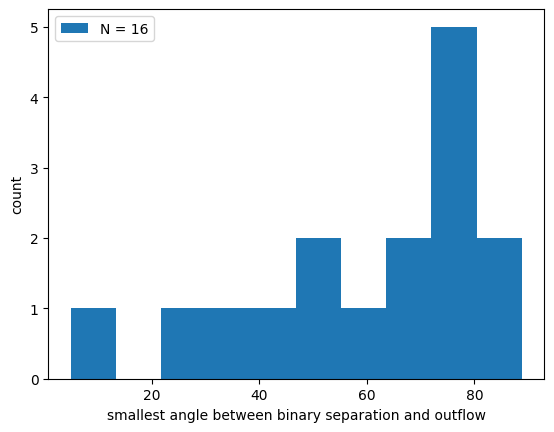

In [ ]:
# This loops through each source field with an angle measurement and creates
# a figure with the separation vector an outflow vector overlayed
smallest_angles = []
for target_name, group in sources.groupby("Main"):

    # open image
    hdulist = fits.open(f"/Volumes/Alpha/Research/data/{target_name.casefold()}/{target_name.casefold()}__s15__12co.fits")
    hdu = hdulist[0]

    # extract center coords
    center_ra = hdu.header['OBSRA']
    center_dec = hdu.header['OBSDEC']

    # set center and size of cutout
    center = SkyCoord(center_ra, center_dec, unit=u.degree)
    size = np.array([39, 39]) * u.arcsecond


    ### calculate outflow vector
    angle_north = group.iloc[0]["Angle"]
    angle_east_rad = np.radians(90 - angle_north)
    vector_tip = np.array([
        center_ra + 0.005 * np.cos(angle_east_rad),
        center_dec + 0.005 * np.sin(angle_east_rad)
    ])
    vector_origin_pix = fig.world2pixel(center.ra.deg, center.dec.deg)
    outflow_tip_pix = fig.world2pixel(vector_tip[0], vector_tip[1])
    outflow_vector = np.array([outflow_tip_pix[0] - vector_origin_pix[0], outflow_tip_pix[1] - vector_origin_pix[1]])


    ### calculate separation vector
    star_a = np.array([group.iloc[0]['RA'], group.iloc[0]['Dec']])
    star_b = np.array([group.iloc[1]['RA'], group.iloc[1]['Dec']])
    star_a_pix = fig.world2pixel(star_a[0], star_a[1])
    star_b_pix = fig.world2pixel(star_b[0], star_b[1])
    separation_vector = np.array([star_a_pix[0] - star_b_pix[0], star_a_pix[1] - star_b_pix[1]])
    separation_vector = np.linalg.norm(outflow_vector) * separation_vector / np.linalg.norm(separation_vector)


    # display angle between outflow and separation in top left corner
    angle = np.min([angle_between_vectors(outflow_vector, separation_vector), 180-angle_between_vectors(outflow_vector, separation_vector)])

    # save image
    smallest_angles.append({"Main": target_name, "smallest_angle": angle})

df = pd.DataFrame(smallest_angles)

plt.hist(df['smallest_angle'], label=f"N = {len(df)}")
plt.legend(loc='upper left')
plt.xlabel("smallest angle between binary separation and outflow")
plt.ylabel("count")
plt.savefig("../results/outflow_alignment/histogram.png")